<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab6_2_landcover_phenology_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cobertura del Suelo y Fenología de la Vegetación
## Ciencia de Datos Ambientales – Aplicado al Perú

**Tema:** ¿Cómo podemos analizar los patrones de cobertura del suelo y realizar un seguimiento de la dinámica de la vegetación a lo largo del tiempo?

**Duración:** 75 minutos

**Objetivos de aprendizaje:**
- Trabajar con productos de cobertura del suelo (ESA WorldCover, MapBiomas)
- Calcular estadísticas de cobertura y analizar patrones espaciales en el Perú
- Comprender los conceptos de fenología de la vegetación
- Construir y analizar series de tiempo NDVI con MODIS
- Extraer métricas fenológicas (inicio de estación, pico, senescencia)
- Comparar fenología entre tipos de cobertura y años en el contexto peruano

---

In [ ]:
# Install required packages
!pip install geemap earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.0 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='utec-ingambiental-01')  # <-- REEMPLAZA con tu Project ID pesronal: ee-cmillanarancibia,



In [ ]:
# Área de estudio: región de Ucayali (Amazonia peruana)
ucayali = ee.Geometry.Rectangle([-76.5, -11.5, -73.5, -7.5])

# Puntos de monitoreo representativos del Perú
punto_bosque       = ee.Geometry.Point([-75.0, -9.0])   # Bosque Amazónico
punto_agricultura  = ee.Geometry.Point([-76.0, -10.5])  # Zona agrícola
punto_ciudad       = ee.Geometry.Point([-74.5539, -8.3791])  # Pucallpa

---
## Parte 1: Productos de Cobertura del Suelo

### 1.1 Introducción a los productos de cobertura

En lugar de crear nuestros propios mapas de cobertura (que requiere ML supervisado), podemos usar **productos existentes** creados por agencias gubernamentales e instituciones de investigación.

### Productos disponibles para el Perú

| Producto | Resolución | Cobertura | Clases | Actualización |
|----------|-----------|-----------|--------|---------------|
| **ESA WorldCover** | 10 m | Global | 11 | Anual |
| **MapBiomas Perú** | 30 m | Perú | 27+ | Anual |
| **MODIS Land Cover** | 500 m | Global | 17 | Anual |
| **Copernicus Global** | 100 m | Global | 23 | Annual |
| **PRODES (INPE)** | 30 m | Amazonia | Deforestación | Anual |

### Clases ESA WorldCover (para el Perú)

| Código | Clase | Importancia en Perú |
|--------|-------|---------------------|
| 10 | Bosque | Amazonia (~60% del territorio) |
| 20 | Arbustos | Yungas, jalca |
| 30 | Pastizales | Puna, jalca |
| 40 | Cultivos | Costa, valles andinos |
| 50 | Zona urbana | Lima, Arequipa, Cusco |
| 60 | Suelo desnudo | Desierto costero, morrenas |
| 80 | Cuerpos de agua | Lago Titicaca, ríos amazónicos |
| 90 | Humedales | Pantanos amazónicos |
| 95 | Manglares | Costa norte (Tumbes) |

In [ ]:
# Cargar ESA WorldCover 2021
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first().select('Map')
wc_ucayali = worldcover.clip(ucayali)

# Paleta de colores ESA WorldCover
vis_wc = {
    'min': 10, 'max': 95,
    'palette': [
        '006400',
        'FFBB22',
        'FFFF4C',
        'F096FF',
        'FA0000',
        'B4B4B4',
        'F0F0F0',
        '0064C8',
        '0096A0',
        '00CF75',
        'FAE6A0'
    ]
}

Map = geemap.Map(center=[-9.5, -75.0], zoom=7)
Map.addLayer(wc_ucayali, {}, 'ESA WorldCover 2021 – Ucayali')

# Add legend using keys and colors lists
legend_keys = ['Cobertura arbórea', 'Matorrales', 'Pradera', 'Tierras de cultivo',
               'Construcción', 'Vegetación escasa o nula', 'Nieve y hielo', 'Cuerpos de agua permanentes',
               'Humedal herbáceo', 'Manglares', 'Musgo y líquenes']
legend_colors = ['#006400', '#ffbb22', '#ffff4c', '#f096ff', '#fa0000',
                 '#b4b4b4', '#f0f0f0', '#0064c8', '#0096a0', '#00cf75', '#fae6a0']

Map.add_legend(title='ESA WorldCover Land Cover', keys=legend_keys, colors=legend_colors)

Map

Map(center=[-9.5, -75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# Calcular área por clase de cobertura
imagen_area = ee.Image.pixelArea().addBands(wc_ucayali)

areas = imagen_area.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='clase'),
    geometry=ucayali,
    scale=100,
    maxPixels=1e9
).getInfo()

# Diccionario de nombres de clases
nombres_clases = {
    10: 'Bosques',
    20: 'Arbustos',
    30: 'Pastizales',
    40: 'Cultivos',
    50: 'Zona urbana',
    60: 'Suelo desnudo',
    70: 'Nieve y hielo',
    80: 'Cuerpos de agua',
    90: 'Humedales herbáceos',
    95: 'Manglares'
}

area_total = sum([g['sum'] for g in areas['groups']])

print("Cobertura del Suelo – Región Ucayali (ESA WorldCover 2021):")
print(f"{'Clase':<22} {'Área (km²)':>12} {'Porcentaje':>12}")
print("=" * 48)

resultados = []
for grupo in sorted(areas['groups'], key=lambda x: -x['sum']):
    codigo   = int(grupo['clase'])
    area_km2 = grupo['sum'] / 1e6
    pct      = grupo['sum'] / area_total * 100
    nombre   = nombres_clases.get(codigo, f'Clase {codigo}')
    print(f"{nombre:<22} {area_km2:>12.1f} {pct:>11.1f}%")
    resultados.append({'clase': nombre, 'area_km2': area_km2, 'pct': pct})

print(f"{'TOTAL':<22} {area_total/1e6:>12.1f} {'100.0%':>12}")

Cobertura del Suelo – Región Ucayali (ESA WorldCover 2021):
Clase                    Área (km²)   Porcentaje
Bosques                    119406.5        81.9%
Pastizales                  22549.7        15.5%
Cuerpos de agua              1836.8         1.3%
Humedales herbáceos           516.5         0.4%
Arbustos                      489.1         0.3%
Suelo desnudo                 426.8         0.3%
Cultivos                      281.3         0.2%
Zona urbana                   218.1         0.1%
Nieve y hielo                  11.2         0.0%
TOTAL                      145736.0       100.0%


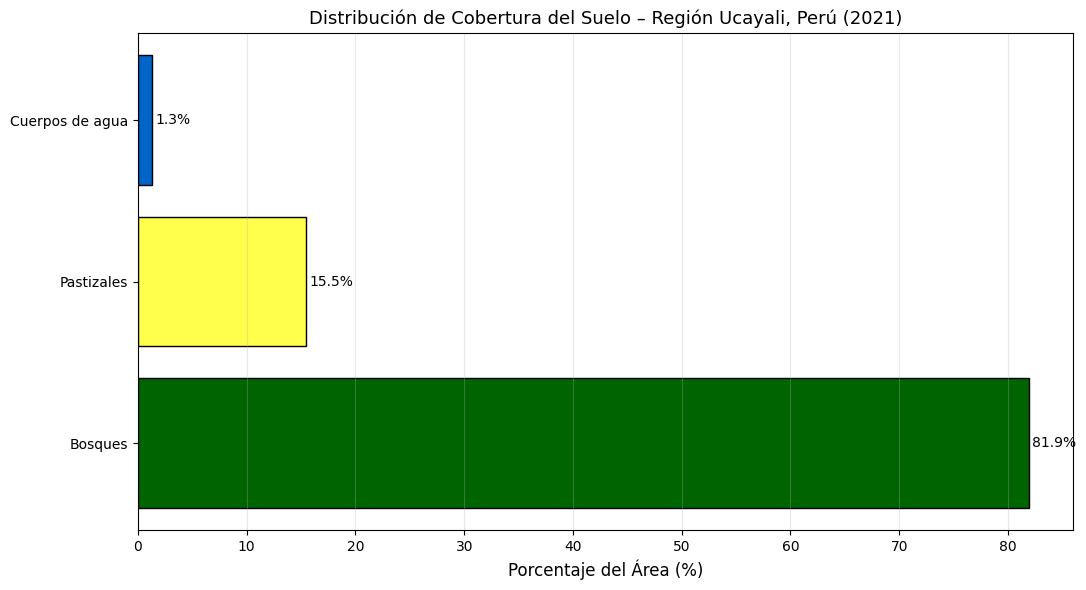

In [ ]:
# Visualizar distribución de cobertura
df_cobertura = pd.DataFrame(resultados)
df_cobertura = df_cobertura[df_cobertura['pct'] > 1] # Only classes > 1%

colores_cobertura = {
    'Bosques': '#006400',
    'Arbustos': '#FFBB22',
    'Pastizales': '#FFFF4C',
    'Cultivos': '#F096FF',
    'Zona urbana': '#FA0000',
    'Suelo desnudo': '#B4B4B4',
    'Nieve y hielo': '#F0F0F0',
    'Cuerpos de agua': '#0064C8',
    'Humedales herbáceos': '#0096a0',
    'Manglares': '#00cf75',
    'Musgo y líquenes': '#FAE6A0'

}
colores_barras = [colores_cobertura.get(c, 'gray') for c in df_cobertura['clase']]

fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(df_cobertura['clase'], df_cobertura['pct'], color=colores_barras, edgecolor='black')
ax.set_xlabel('Porcentaje del Área (%)', fontsize=12)
ax.set_title('Distribución de Cobertura del Suelo – Región Ucayali, Perú (2021)', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

for barra, pct in zip(barras, df_cobertura['pct']):
    ax.text(barra.get_width() + 0.3, barra.get_y() + barra.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 1.2 Reclasificar y Simplificar Clases

A veces necesitamos **simplificar** las clases de cobertura para el análisis.
Por ejemplo, podemos agrupar las 11 clases de WorldCover en 5 grandes categorías
más fáciles de comparar e interpretar.

In [ ]:
# Reclasificar WorldCover en categorías simplificadas

# Clases originales → categorías simplificadas
#   1 = Agua
#   2 = Urbano
#   3 = Bosque
#   4 = Vegetación abierta (arbustos, pastizales, cultivos)
#   5 = Suelo desnudo / Otros

desde_clases = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
hacia_clases = [ 3,  4,  4,  4,  2,  5,  5,  1,  4,  3,   5]

wc_simplificado = wc_ucayali.remap(desde_clases, hacia_clases).rename('cobertura_simple')

# Paleta para las clases simplificadas
vis_simple = {
    'min': 1, 'max': 5,
    'palette': ['#0064C8', '#FA0000', '#006400', '#FFBB22', '#B4B4B4']
    # Agua, Urbano, Bosque, Vegetación abierta, Suelo desnudo
}

Mapa_simple = geemap.Map(center=[-9.5, -75.0], zoom=7)
Mapa_simple.addLayer(wc_simplificado, vis_simple, 'WorldCover Simplificado (5 clases)')

# Añadir leyenda
legend_keys   = ['Agua', 'Urbano', 'Bosque', 'Vegetación abierta', 'Suelo desnudo']
legend_colors = ['#0064C8', '#FA0000', '#006400', '#FFBB22', '#B4B4B4']
Mapa_simple.add_legend(title='Cobertura Simplificada', keys=legend_keys, colors=legend_colors)
Mapa_simple

Map(center=[-9.5, -75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# Calcular área de las clases simplificadas
area_simple = ee.Image.pixelArea().addBands(wc_simplificado)

areas_s = area_simple.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='clase'),
    geometry=ucayali,
    scale=100,
    maxPixels=1e9
).getInfo()

nombres_simples = {1: 'Agua', 2: 'Urbano', 3: 'Bosque',
                   4: 'Vegetación abierta', 5: 'Suelo desnudo'}
area_total_s = sum([g['sum'] for g in areas_s['groups']])

print("Cobertura Simplificada – Región Ucayali:")
print(f"{'Categoría':<22} {'Área (km²)':>12} {'Porcentaje':>12}")
print("=" * 48)
for g in sorted(areas_s['groups'], key=lambda x: -x['sum']):
    cod   = int(g['clase'])
    area  = g['sum'] / 1e6
    pct   = g['sum'] / area_total_s * 100
    nombre = nombres_simples.get(cod, f'Clase {cod}')
    print(f"{nombre:<22} {area:>12.1f} {pct:>11.1f}%")

Cobertura Simplificada – Región Ucayali:
Categoría                Área (km²)   Porcentaje
Bosque                     119406.5        81.9%
Vegetación abierta          23836.7        16.4%
Agua                         1836.8         1.3%
Suelo desnudo                 437.9         0.3%
Urbano                        218.1         0.1%


### 1.3 Usar la cobertura como máscara

In [ ]:
# Crear máscaras por tipo de cobertura
mask_bosque    = wc_ucayali.eq(10)
mask_cultivos  = wc_ucayali.eq(40)
mask_agua      = wc_ucayali.eq(80)
mask_urbano    = wc_ucayali.eq(50)

# Cargar y procesar Landsat para calcular NDVI promedio por clase
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

def escalar_y_ndvi(img):
    opt = img.select(['SR_B4', 'SR_B5']).multiply(0.0000275).add(-0.2)
    ndvi = opt.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return ndvi

ndvi_verano = (landsat
    .filterDate('2023-07-01', '2023-09-30')
    .filterBounds(ucayali)
    .filter(ee.Filter.lt('CLOUD_COVER', 30))
    .map(escalar_y_ndvi)
    .median()
    .clip(ucayali)
)

# NDVI promedio por cobertura
print("NDVI promedio por tipo de cobertura (época seca 2023):")
print("=" * 45)

for nombre, mascara in [('Bosque', mask_bosque), ('Cultivos', mask_cultivos), ('Urbano', mask_urbano)]:
    ndvi_enmascarado = ndvi_verano.updateMask(mascara)
    media = ndvi_enmascarado.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ucayali, scale=30, maxPixels=1e9
    ).get('NDVI').getInfo()
    if media:
        print(f"  {nombre:<15}: {media:.3f}")

NDVI promedio por tipo de cobertura (época seca 2023):
  Bosque         : 0.776
  Cultivos       : 0.509
  Urbano         : 0.324


---
## Parte 2: Fenología de la Vegetación

### 2.1 ¿Qué es la Fenología?

La **fenología** es el estudio de los ciclos estacionales en los seres vivos. Para la vegetación peruana, los eventos fenológicos clave incluyen:

| Evento | Definición | Timing en Perú |
|--------|-----------|----------------|
| **Inicio de estación** | Emergencia foliar, aumento rápido del NDVI | Variable según altitud |
| **Verde máximo** | Máxima actividad fotosintética | Época de lluvias |
| **Senescencia** | Cambio de color y caída de hojas | Inicio de época seca |
| **Dormancia** | Mínima actividad vegetal | Época seca (Andes/Costa) |

### Contexto peruano
- **Amazonia**: vegetación perennifolia con poca variación estacional; ligero "verdor" en época seca
- **Andes (bosques)**: mayor variación; responde a lluvias (oct–abr)
- **Puna/Jalca**: marcada estacionalidad; dormancia en época seca
- **Costa**: depende del riego; El Niño genera verdor inusual

### 2.2 Series de tiempo NDVI con MODIS

In [ ]:
# MODIS MOD13Q1: compositos NDVI de 16 días a 250 m
modis = ee.ImageCollection('MODIS/061/MOD13Q1')

modis_2023 = (modis
    .filterDate('2023-01-01', '2023-12-31')
    .filterBounds(ucayali)
    .select('NDVI')
)

print(f"Imágenes MODIS en 2023: {modis_2023.size().getInfo()}")
print("(Compositos de 16 días = ~23 imágenes por año)")

# Escalar NDVI (almacenado como entero * 10000)
def escalar_modis(img):
    return img.multiply(0.0001).copyProperties(img, ['system:time_start'])

modis_2023 = modis_2023.map(escalar_modis)

Imágenes MODIS en 2023: 23
(Compositos de 16 días = ~23 imágenes por año)


In [ ]:
# Extraer serie temporal NDVI en los tres puntos de monitoreo
sitios = [
    {'nombre': 'Bosque Amazónico', 'punto': punto_bosque},
    {'nombre': 'Zona Agrícola',    'punto': punto_agricultura},
    {'nombre': 'Pucallpa (urbano)', 'punto': punto_ciudad},
]

lista_imagenes = modis_2023.toList(modis_2023.size())
n_imagenes     = modis_2023.size().getInfo()

registros = []
for sitio in sitios:
    for i in range(n_imagenes):
        imagen = ee.Image(lista_imagenes.get(i))
        fecha  = imagen.date().format('YYYY-MM-dd').getInfo()
        valor  = imagen.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=sitio['punto'],
            scale=250
        ).get('NDVI').getInfo()

        if valor is not None:
            registros.append({
                'fecha': fecha,
                'nombre': sitio['nombre'],
                'NDVI': valor
            })

df = pd.DataFrame(registros)
df['fecha'] = pd.to_datetime(df['fecha'])
df['dda']   = df['fecha'].dt.dayofyear  # día del año

print(f"Extraídas {len(df)} observaciones")
df.head()

Extraídas 69 observaciones


,fecha,nombre,NDVI,dda
0,2023-01-01,Bosque Amazónico,0.7748,1
1,2023-01-17,Bosque Amazónico,0.6744,17
2,2023-02-02,Bosque Amazónico,0.1688,33
3,2023-02-18,Bosque Amazónico,0.0834,49
4,2023-03-06,Bosque Amazónico,0.6436,65


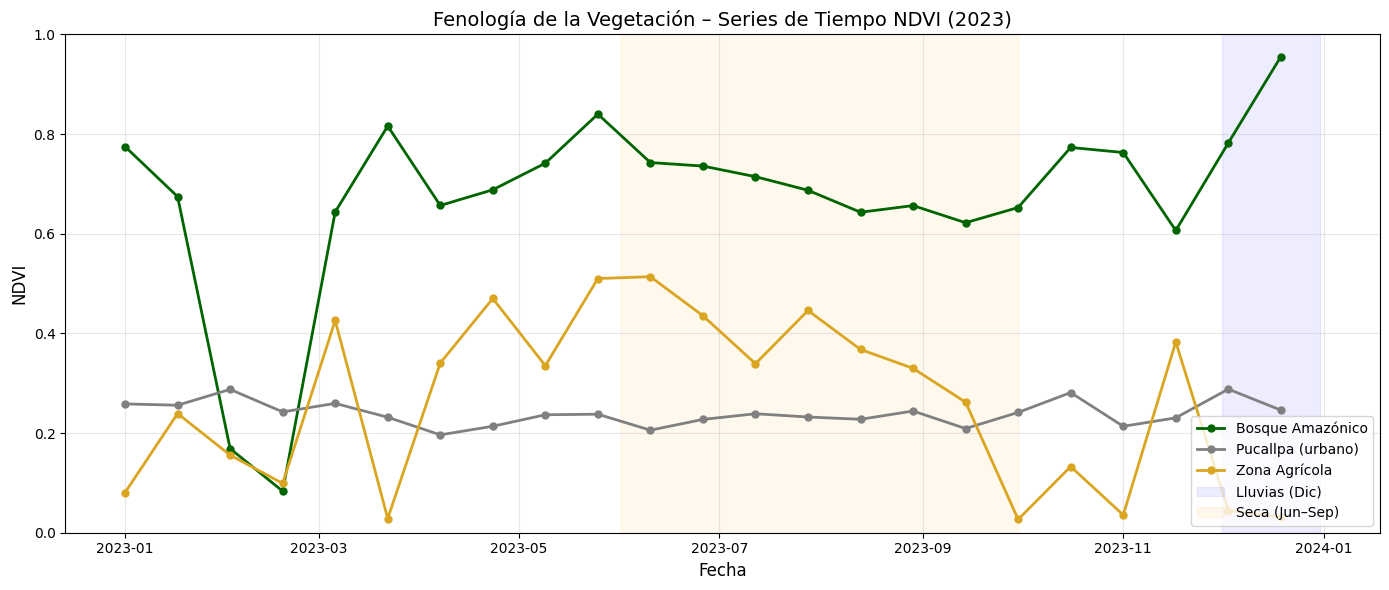

In [ ]:
# Graficar series de tiempo NDVI
fig, ax = plt.subplots(figsize=(14, 6))

colores = {
    'Bosque Amazónico':    'darkgreen',
    'Zona Agrícola':       'goldenrod',
    'Pucallpa (urbano)':   'gray'
}

for nombre, grupo in df.groupby('nombre'):
    grupo = grupo.sort_values('fecha')
    ax.plot(grupo['fecha'], grupo['NDVI'], 'o-',
            label=nombre, color=colores[nombre], linewidth=2, markersize=5)

# Sombreado de épocas
ax.axvspan(pd.Timestamp('2023-12-01'), pd.Timestamp('2023-12-31'), alpha=0.07, color='blue', label='Lluvias (Dic)')
ax.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2023-09-30'), alpha=0.07, color='orange', label='Seca (Jun–Sep)')

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Fenología de la Vegetación – Series de Tiempo NDVI (2023)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 2.3 Extraer Métricas Fenológicas

Métricas clave que podemos extraer de las series temporales de NDVI:

| Métrica | Definición | Cálculo |
|--------|------------|-------------|
| **Inicio de temporada (SOS)** | Fecha de reverdecimiento | El NDVI cruza el umbral (primavera) |
| **NDVI máximo** | Máxima verdor | Valor máximo de NDVI |
| **Fecha máxima** | Momento del máximo | Fecha del pico de NDVI |
| **Fin de temporada (EOS)** | Fecha de senescencia | El NDVI cae por debajo del umbral (otoño) |
| **Duración de la temporada de crecimiento** | Duración | EOS - SOS |
| **Amplitud** | Rango estacional | Pico - Mínimo de NDVI |

In [ ]:
def extraer_metricas_fenologicas(df_sitio):
    """
    Extrae métricas fenológicas de una serie temporal de NDVI.

    Parámetros:
    -----------
    df_sitio : DataFrame con columnas 'fecha', 'dda', 'NDVI'

    Retorna:
    --------
    dict : Métricas fenológicas
    """
    df_sitio = df_sitio.sort_values('dda').copy()
    df_sitio['NDVI_suave'] = df_sitio['NDVI'].rolling(window=3, center=True, min_periods=1).mean()

    metricas = {}

    # Pico de NDVI
    idx_pico = df_sitio['NDVI_suave'].idxmax()
    metricas['ndvi_pico']  = df_sitio.loc[idx_pico, 'NDVI_suave']
    metricas['fecha_pico'] = df_sitio.loc[idx_pico, 'fecha']
    metricas['dda_pico']   = df_sitio.loc[idx_pico, 'dda']

    # NDVI mínimo
    idx_min = df_sitio['NDVI_suave'].idxmin()
    metricas['ndvi_min'] = df_sitio.loc[idx_min, 'NDVI_suave']

    # Amplitud
    metricas['amplitud'] = metricas['ndvi_pico'] - metricas['ndvi_min']

    # Umbral para Inicio/Fin de Estación (50% de la amplitud)
    umbral = metricas['ndvi_min'] + 0.5 * metricas['amplitud']

    # Inicio de Estación Verde (primera vez que supera el umbral en la primera mitad del año)
    primera_mitad = df_sitio[(df_sitio['dda'] >= 30) & (df_sitio['dda'] <= 200)]
    sobre_umbral  = primera_mitad[primera_mitad['NDVI_suave'] >= umbral]
    if len(sobre_umbral) > 0:
        metricas['fecha_inicio'] = sobre_umbral.iloc[0]['fecha']
        metricas['dda_inicio']   = sobre_umbral.iloc[0]['dda']

    # Fin de Estación Verde (primera vez que baja del umbral en segunda mitad)
    segunda_mitad  = df_sitio[(df_sitio['dda'] >= 200) & (df_sitio['dda'] <= 330)]
    bajo_umbral    = segunda_mitad[segunda_mitad['NDVI_suave'] <= umbral]
    if len(bajo_umbral) > 0:
        metricas['fecha_fin'] = bajo_umbral.iloc[0]['fecha']
        metricas['dda_fin']   = bajo_umbral.iloc[0]['dda']

    # Duración de la estación verde
    if 'dda_inicio' in metricas and 'dda_fin' in metricas:
        metricas['duracion_estacion'] = metricas['dda_fin'] - metricas['dda_inicio']

    return metricas


# Calcular métricas para cada tipo de cobertura
print("Métricas Fenológicas (2023)")
print("=" * 60)

todas_metricas = {}
for nombre in df['nombre'].unique():
    df_sitio = df[df['nombre'] == nombre].copy()
    metricas = extraer_metricas_fenologicas(df_sitio)
    todas_metricas[nombre] = metricas

    print(f"\n{nombre}:")
    print(f"  NDVI máximo: {metricas['ndvi_pico']:.3f}")
    print(f"  Fecha pico:  {metricas['fecha_pico'].strftime('%d %B')} (DDA {metricas['dda_pico']})")
    print(f"  NDVI mínimo: {metricas['ndvi_min']:.3f}")
    print(f"  Amplitud:    {metricas['amplitud']:.3f}")
    if 'fecha_inicio' in metricas:
        print(f"  Inicio est.: {metricas['fecha_inicio'].strftime('%d %B')} (DDA {metricas['dda_inicio']})")
    if 'fecha_fin' in metricas:
        print(f"  Fin est.:    {metricas['fecha_fin'].strftime('%d %B')} (DDA {metricas['dda_fin']})")
    if 'duracion_estacion' in metricas:
        print(f"  Duración est.: {metricas['duracion_estacion']} días")

Métricas Fenológicas (2023)

Bosque Amazónico:
  NDVI máximo: 0.869
  Fecha pico:  19 December (DDA 353)
  NDVI mínimo: 0.299
  Amplitud:    0.570
  Inicio est.: 22 March (DDA 81)

Zona Agrícola:
  NDVI máximo: 0.486
  Fecha pico:  10 June (DDA 161)
  NDVI mínimo: 0.038
  Amplitud:    0.448
  Inicio est.: 22 March (DDA 81)
  Fin est.:    14 September (DDA 257)
  Duración est.: 176 días

Pucallpa (urbano):
  NDVI máximo: 0.267
  Fecha pico:  17 January (DDA 17)
  NDVI mínimo: 0.214
  Amplitud:    0.053
  Inicio est.: 02 February (DDA 33)
  Fin est.:    28 July (DDA 209)
  Duración est.: 176 días


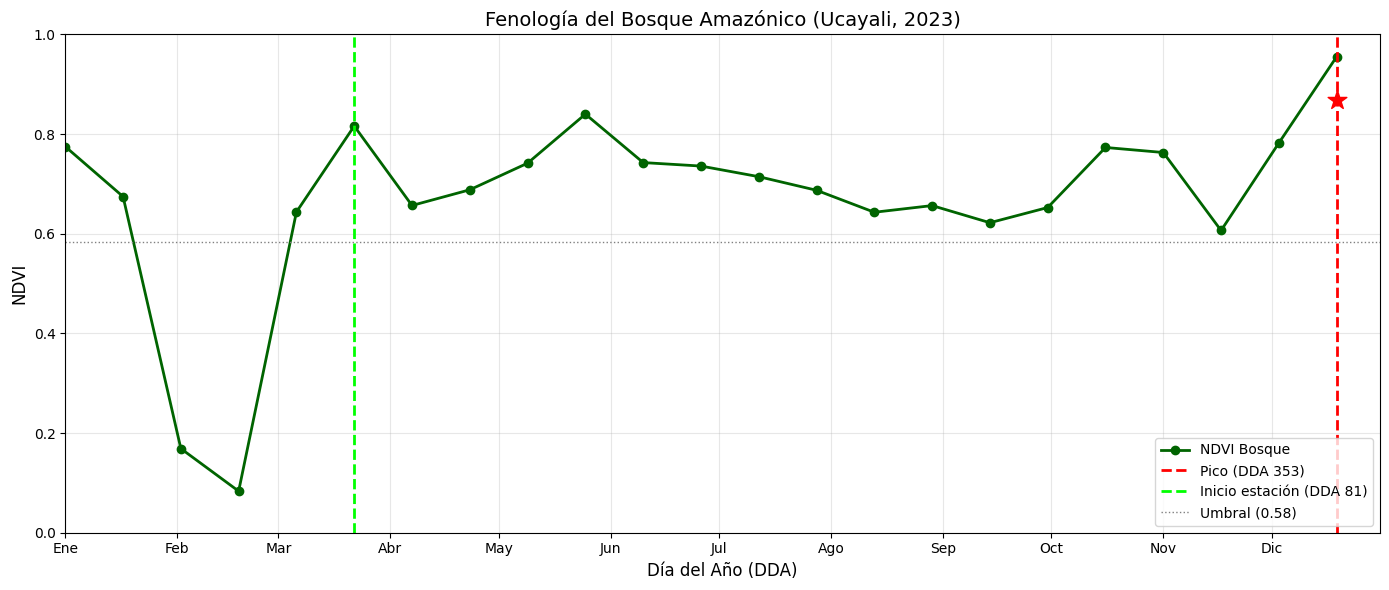

In [ ]:
# Visualizar eventos fenológicos del bosque amazónico
fig, ax = plt.subplots(figsize=(14, 6))

df_bosque = df[df['nombre'] == 'Bosque Amazónico'].sort_values('fecha')
ax.plot(df_bosque['dda'], df_bosque['NDVI'], 'o-', color='darkgreen',
        linewidth=2, markersize=6, label='NDVI Bosque')

m = todas_metricas['Bosque Amazónico']

# Línea del pico
ax.axvline(m['dda_pico'], color='red', linestyle='--', linewidth=2,
           label=f'Pico (DDA {m["dda_pico"]})')
ax.scatter([m['dda_pico']], [m['ndvi_pico']], s=200, c='red', zorder=5, marker='*')

# Inicio y fin si existen
if 'dda_inicio' in m:
    ax.axvline(m['dda_inicio'], color='lime', linestyle='--', linewidth=2,
               label=f'Inicio estación (DDA {m["dda_inicio"]})')
if 'dda_fin' in m:
    ax.axvline(m['dda_fin'], color='orange', linestyle='--', linewidth=2,
               label=f'Fin estación (DDA {m["dda_fin"]})')

# Umbral
umbral = m['ndvi_min'] + 0.5 * m['amplitud']
ax.axhline(umbral, color='gray', linestyle=':', linewidth=1,
           label=f'Umbral ({umbral:.2f})')

ax.set_xlabel('Día del Año (DDA)', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Fenología del Bosque Amazónico (Ucayali, 2023)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 365)
ax.set_ylim(0, 1)

# Etiquetas de meses
inicio_meses = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
nombres_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ax.set_xticks(inicio_meses)
ax.set_xticklabels(nombres_meses)

plt.tight_layout()
plt.show()

### 2.4 Comparación Multianual de Fenología

In [ ]:
# Comparar fenología del bosque en múltiples años
anios = [2019, 2020, 2021, 2022, 2023]
datos_multianio = []

for anio in anios:
    print(f"Procesando {anio}...", end=' ')

    modis_anio = (modis
        .filterDate(f'{anio}-01-01', f'{anio}-12-31')
        .filterBounds(punto_bosque)
        .select('NDVI')
        .map(escalar_modis)
    )

    lista_imgs = modis_anio.toList(modis_anio.size())
    n_imgs     = modis_anio.size().getInfo()

    for i in range(n_imgs):
        img  = ee.Image(lista_imgs.get(i))
        dda  = img.date().getRelative('day', 'year').getInfo() + 1
        ndvi = img.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=punto_bosque,
            scale=250
        ).get('NDVI').getInfo()

        if ndvi is not None:
            datos_multianio.append({'dda': dda, 'ndvi': ndvi, 'anio': anio})

    print(f"listo ({n_imgs} imágenes)")

df_multi = pd.DataFrame(datos_multianio)
print(f"\nDatos multianio: {len(df_multi)} observaciones")

Procesando 2019... listo (23 imágenes)
Procesando 2020... listo (23 imágenes)
Procesando 2021... listo (23 imágenes)
Procesando 2022... listo (23 imágenes)
Procesando 2023... listo (23 imágenes)

Datos multianio: 115 observaciones


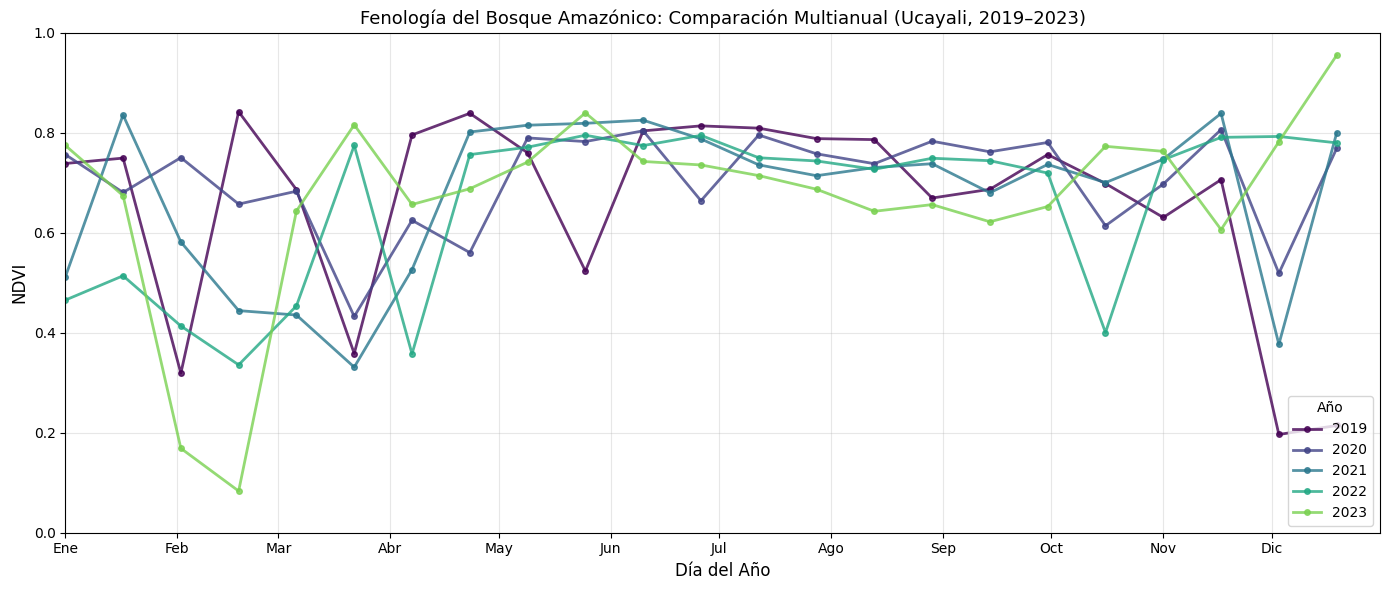

In [ ]:
# Graficar comparación multianual
fig, ax = plt.subplots(figsize=(14, 6))

cmap   = plt.cm.viridis
colores_anio = {anio: cmap(i / len(anios)) for i, anio in enumerate(anios)}

for anio in anios:
    sub = df_multi[df_multi['anio'] == anio].sort_values('dda')
    ax.plot(sub['dda'], sub['ndvi'], 'o-', label=str(anio),
            color=colores_anio[anio], linewidth=2, markersize=4, alpha=0.8)

ax.set_xlabel('Día del Año', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Fenología del Bosque Amazónico: Comparación Multianual (Ucayali, 2019–2023)', fontsize=13)
ax.legend(title='Año', loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 365)
ax.set_ylim(0, 1)
ax.set_xticks(inicio_meses)
ax.set_xticklabels(nombres_meses)

plt.tight_layout()
plt.show()

#### Métricas fenológicas por año

In [ ]:
# Calcular métricas fenológicas para cada año
print("Tendencia Fenológica del Bosque Amazónico (2019–2023):")
print("=" * 65)
print(f"{'Año':<6} {'DDA Pico':>10} {'NDVI Pico':>12} {'DDA Inicio':>12} {'DDA Fin':>10}")
print("-" * 65)

metricas_anuales = []

for anio in anios:
    df_anio = df_multi[df_multi['anio'] == anio].copy()
    df_anio['fecha'] = pd.to_datetime(
        df_anio['dda'].apply(lambda x: f'{anio}-{int(x):03d}'), format='%Y-%j'
    )
    df_anio = df_anio.rename(columns={'ndvi': 'NDVI'})

    m_anio = extraer_metricas_fenologicas(df_anio)
    metricas_anuales.append({'anio': anio, **m_anio})

    inicio_str = str(m_anio.get('dda_inicio', 'N/A'))
    fin_str    = str(m_anio.get('dda_fin', 'N/A'))
    print(f"{anio:<6} {m_anio['dda_pico']:>10} {m_anio['ndvi_pico']:>12.3f} "
          f"{inicio_str:>12} {fin_str:>10}")

# ¿Hay tendencia en el pico?
import numpy as np
df_met = pd.DataFrame(metricas_anuales)
picos  = [m['dda_pico'] for m in metricas_anuales]
tendencia_pico = np.polyfit(anios, picos, 1)[0]
print(f"\nCambio medio en DDA del pico NDVI: {tendencia_pico:+.1f} días/año")

Tendencia Fenológica del Bosque Amazónico (2019–2023):
Año      DDA Pico    NDVI Pico   DDA Inicio    DDA Fin
-----------------------------------------------------------------
2019          177        0.809           33        N/A
2020          145        0.792           33        N/A
2021          145        0.820           33        N/A
2022          161        0.788           97        N/A
2023          353        0.869           81        N/A

Cambio medio en DDA del pico NDVI: +36.8 días/año


### 2.5 Patrones Espaciales de Fenología

Hasta ahora hemos analizado la fenología en puntos específicos. Con MODIS podemos
crear **mapas espaciales** que muestren cuándo ocurre el pico de NDVI en toda la región.

Usamos `qualityMosaic('NDVI')` de GEE: selecciona para cada píxel el compuesto de 16 días
con el NDVI más alto, junto con el día del año (DDA) en que ocurrió.

In [ ]:
# Función para añadir el DDA como banda
def agregar_dda(img):
    """Añade el día del año (DDA) como banda a cada imagen MODIS."""
    dda = ee.Number(img.date().getRelative('day', 'year')).add(1)
    return img.addBands(ee.Image.constant(dda).rename('DDA').toInt())

# Añadir DDA a cada imagen
modis_con_dda = modis_2023.map(agregar_dda)

# qualityMosaic: para cada píxel, selecciona el compuesto con mayor NDVI
# y conserva el DDA de ese compuesto
mapa_pico_dda = modis_con_dda.qualityMosaic('NDVI').select('DDA').clip(ucayali)

# Mapa del NDVI máximo
mapa_ndvi_max = modis_2023.max().clip(ucayali)

In [ ]:
# Visualizar patrones espaciales de fenología
Mapa_fenol = geemap.Map(center=[-9.5, -75.0], zoom=7)

# Capa 1: Valor máximo de NDVI en 2023
Mapa_fenol.addLayer(
    mapa_ndvi_max,
    {'min': 0.3, 'max': 0.9,
     'palette': ['brown', 'yellow', 'lightgreen', 'green', 'darkgreen']},
    'NDVI Máximo 2023'
)

# Capa 2: DDA del pico (cuándo ocurrió el máximo NDVI)
Mapa_fenol.addLayer(
    mapa_pico_dda,
    {'min': 50, 'max': 350,
     'palette': ['purple', 'blue', 'cyan', 'green', 'yellow', 'orange', 'red']},
    'DDA del Pico NDVI (cuándo fue el máximo)'
)

Mapa_fenol.add_colorbar(
    {'min': 50, 'max': 350,
     'palette': ['purple', 'blue', 'cyan', 'green', 'yellow', 'orange', 'red']},
    label='Día del Año (DDA) del Pico de NDVI'
)

Mapa_fenol

Map(center=[-9.5, -75.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

**Cómo interpretar el mapa de DDA del pico:**

- **Colores azul/morado** (DDA 50–150, feb–may): El NDVI alcanza su máximo al final de la
  época de lluvias, típico de bosques densos que responden con leve retraso.
- **Colores verde/amarillo** (DDA 150–250, jun–sep): Pico tardío, puede indicar vegetación
  secundaria o cultivos con siembra tardía.
- **Colores naranja/rojo** (DDA 250–350, sep–dic): El máximo ocurre en época seca, posiblemente
  relacionado con zonas con riego o vegetación de ciclo inverso.

---
## 🔬 Ejercicio

Basado en el análisis de fenología:

1. ¿Qué tipo de cobertura (Bosque, Agrícola, Urbano) tiene la **mayor amplitud fenológica**? ¿Por qué?
2. ¿Cuál tiene el **NDVI máximo más alto**?
3. Explica por qué la zona agrícola muestra un patrón fenológico diferente al bosque.

> **Pista:** Considera los calendarios agrícolas de Ucayali, la influencia del riego, y las diferencias entre vegetación natural y cultivada.

In [ ]:
# Tu análisis aquí
print("Comparación de métricas por tipo de cobertura:")
print("=" * 55)
print(f"{'Cobertura':<22} {'NDVI Pico':>10} {'Amplitud':>10} {'Duración (días)':>16}")
print("-" * 55)

for nombre, m in todas_metricas.items():
    dur = m.get('duracion_estacion', 'N/A')
    print(f"{nombre:<22} {m['ndvi_pico']:>10.3f} {m['amplitud']:>10.3f} {str(dur):>16}")

Comparación de métricas por tipo de cobertura:
Cobertura               NDVI Pico   Amplitud  Duración (días)
-------------------------------------------------------
Bosque Amazónico            0.869      0.570              N/A
Zona Agrícola               0.486      0.448              176
Pucallpa (urbano)           0.267      0.053              176


---
## Resumen

### Productos de Cobertura del Suelo

| Producto | Uso en Perú |
|----------|-------------|
| **ESA WorldCover** | Análisis global de cobertura (10m) |
| **MapBiomas Perú** | Cambio de cobertura detallado (30m) |
| **MODIS Land Cover** | Cambio anual a gran escala |

### Métricas Fenológicas

| Métrica | Definición | Significado en Perú |
|---------|-----------|---------------------|
| Inicio de Estación (IEV) | Fecha de inicio del verde | Inicio de lluvias/siembra |
| NDVI Máximo | Máximo verdor | Plena cobertura foliar |
| Fin de Estación (FEV) | Fecha de fin del verde | Inicio época seca/cosecha |
| Amplitud | Pico – Mínimo NDVI | Contraste estacional |

### Operaciones GEE clave

| Tarea | Código |
|------|------|
| Cargar cobertura terrestre | `ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021')` |
| Reclasificar | `image.remap(from_list, to_list)` |
| Crear máscara | `image.eq(value)` |
| Área por clase | `reduceRegion(ee.Reducer.sum().group())` |
| Momento pico | `collection.qualityMosaic('NDVI')` |
| Extracción de series temporales | `image.reduceRegion()` en bucle |